In [ ]:
# finding the palm lines 

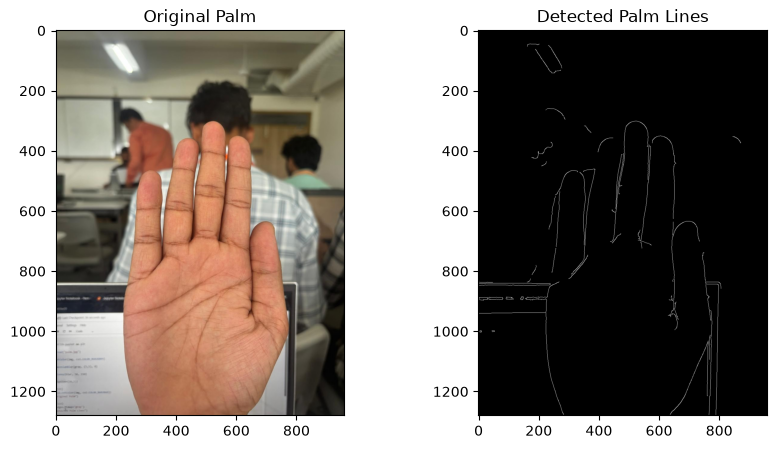

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("palm1.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Palm")

plt.subplot(122)
plt.imshow(edges, cmap='gray')
plt.title("Detected Palm Lines")

plt.show()

In [ ]:
#detecting the face

In [6]:
import cv2

# Load face detector
face = cv2.CascadeClassifier(cv2.data.haarcascades +
                             "haarcascade_frontalface_default.xml")

# Open webcam
cap = cv2.VideoCapture(0)

while True:
    ret, img = cap.read()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face.detectMultiScale(gray, 1.1, 5)

    # Draw rectangle
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    cv2.imshow("Face Detection", img)

    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [7]:
import cv2
import numpy as np

cap = cv2.VideoCapture("road.mp4")
# Use 0 for webcam:
# cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.resize(frame, (800, 600))

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(blur, 50, 150)

    height, width = edges.shape

    mask = np.zeros_like(edges)

    polygon = np.array([[
        (100, height),
        (width-100, height),
        (width//2, height//2)
    ]], np.int32)

    cv2.fillPoly(mask, polygon, 255)

    cropped = cv2.bitwise_and(edges, mask)

    lines = cv2.HoughLinesP(
        cropped,
        2,
        np.pi/180,
        100,
        minLineLength=40,
        maxLineGap=50
    )

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(frame,
                     (x1, y1),
                     (x2, y2),
                     (0, 255, 0),
                     5)

    cv2.imshow("Lane Detection", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

In [8]:
import cv2

cap = cv2.VideoCapture(0)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

while cap.isOpened():

    diff = cv2.absdiff(frame1, frame2)

    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)

    dilated = cv2.dilate(thresh, None, iterations=3)

    contours, _ = cv2.findContours(
        dilated,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:

        if cv2.contourArea(contour) < 1000:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            frame1,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            frame1,
            "Movement Detected",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2
        )

    cv2.imshow("Movement Tracking", frame1)

    frame1 = frame2
    ret, frame2 = cap.read()

    if cv2.waitKey(40) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [9]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame,
                        cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:
        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (255,0,0),
            2
        )

    cv2.imshow("Face Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()